In [1]:
from diffrax import diffeqsolve, Dopri5, ODETerm, SaveAt, PIDController, SemiImplicitEuler, Kvaerno5, Dopri8
import jax.numpy as jnp
import numpy as np
import jax.scipy.special as sp
from scipy.fft import fft, fftfreq
from matplotlib import pyplot as plt

In [44]:
def vector_field(t, y, args):
    x = y[0]
    v = y[1]
    f = - 100 * x / (1 + jnp.exp(x))
    return jnp.array([v, f])


# vector_field = lambda t, y, args: jnp.array([-y[1], y[0]])
SAMPLE_RATE = 1000  # Hertz
DURATION = 5  # Seconds
time_steps = np.linspace(0, DURATION, SAMPLE_RATE * DURATION, endpoint=False)

term = ODETerm(vector_field)
solver = Dopri8()
saveat = SaveAt(ts=time_steps)
stepsize_controller = PIDController(rtol=1e-8, atol=1e-8)

def get_solution(v0):
    sol = diffeqsolve(
                term,
                solver,
                max_steps=100000,
                t0=0,
                t1=DURATION,
                dt0=1/SAMPLE_RATE,
                y0=jnp.array([0,v0]),
                saveat=saveat,
                stepsize_controller=stepsize_controller
            )
    return sol


def get_switchpoints(array, other_array=None):
    switch_points = np.where(array[1:] * array[0:-1] < 0)[0]
    if other_array is not None:
        return other_array[switch_points]
    else:
        return switch_points

In [45]:
num_initial_conditions = 101
max_initial_velocity = 10
min_initial_velocity = 1
num_points = SAMPLE_RATE * DURATION
xs = np.linspace(min_initial_velocity, max_initial_velocity, num_initial_conditions)
positions = np.zeros((num_initial_conditions, num_points))
velocities = np.zeros((num_initial_conditions, num_points))

for k, v0 in enumerate(xs):
    color = (0, 0.5, k / len(xs))
    try:
        sol = get_solution(v0)
        positions[k, :] = sol.ys[:, 0]
        velocities[k, :] = sol.ys[:, 1]
    except:
        pass

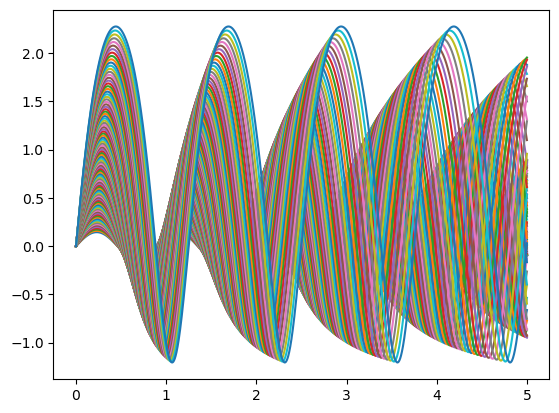

In [46]:
for k in range(num_initial_conditions):
    plt.plot(time_steps, positions[k])

In [47]:
frequencies = np.zeros(num_initial_conditions)
amplitudes = np.zeros(num_initial_conditions)

for k in range(num_initial_conditions):
    times_at_the_origin = get_switchpoints(positions[k], other_array=time_steps)
    positions_at_zero_velocity = get_switchpoints(velocities[k], other_array=positions[k])
    frequencies[k] = np.mean(1 / np.diff(times_at_the_origin))
    amplitudes[k] = np.mean(np.abs(positions_at_zero_velocity))
    

Text(0, 0.5, 'Amplitude (m)')

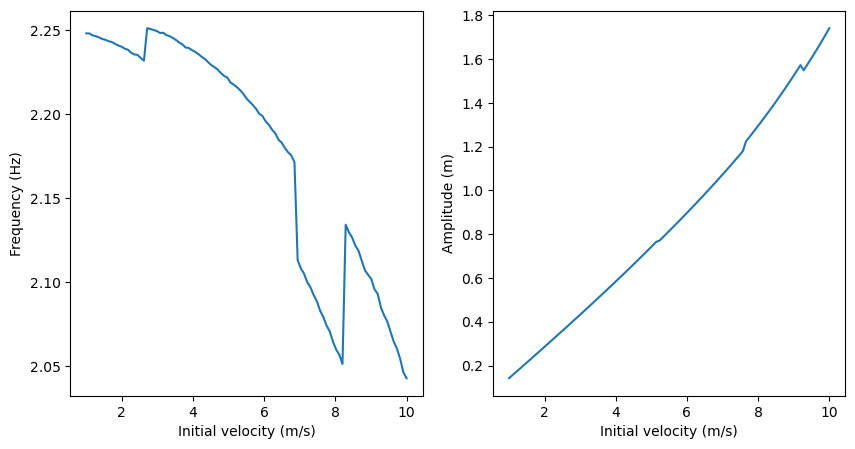

In [48]:
fig, ax = plt.subplots(figsize=(10, 5), ncols=2)
ax[0].plot(xs, frequencies)
ax[1].plot(xs, amplitudes)

ax[0].set_xlabel("Initial velocity (m/s)")
ax[1].set_xlabel("Initial velocity (m/s)")
ax[0].set_ylabel("Frequency (Hz)")
ax[1].set_ylabel("Amplitude (m)")